In [1]:
import pandas as pd

In [2]:
from nsepy import get_history as gh
import datetime as dt

In [5]:
from nselib import capital_market as cm

# Define dates as strings in DD-MM-YYYY format
start_date = '01-06-2021'
end_date = '05-01-2022'

# Use the correct function: price_volume_data
stk_data = cm.price_volume_data(symbol='TATACOFFEE', from_date=start_date, to_date=end_date)

print(stk_data.head())

       Symbol Series         Date  PrevClose  OpenPrice  HighPrice  LowPrice  \
0  TATACOFFEE     EQ  05-Jan-2022     217.80     218.50      218.7    214.30   
1  TATACOFFEE     EQ  04-Jan-2022     214.05     214.90      220.8    212.45   
2  TATACOFFEE     EQ  03-Jan-2022     213.15     213.95      216.9    212.30   
3  TATACOFFEE     EQ  31-Dec-2021     208.50     208.90      216.2    208.40   
4  TATACOFFEE     EQ  30-Dec-2021     211.35     211.45      211.5    207.90   

   LastPrice  ClosePrice  AveragePrice TotalTradedQuantity        Turnover₹  \
0     214.65      214.85        215.72           13,50,483  29,13,25,687.40   
1     217.40      217.80        217.41           34,77,443  75,60,37,979.15   
2     214.30      214.05        214.76           15,25,259  32,75,66,528.25   
3     213.70      213.15        213.37           30,45,699  64,98,54,073.20   
4     208.80      208.50        209.36            9,77,484  20,46,47,553.50   

  No.ofTrades  
0      12,079  
1      28,87

In [6]:
stk_data

,Symbol,Series,Date,PrevClose,OpenPrice,HighPrice,LowPrice,LastPrice,ClosePrice,AveragePrice,TotalTradedQuantity,Turnover₹,No.ofTrades
0,TATACOFFEE,EQ,05-Jan-2022,217.80,218.50,218.70,214.30,214.65,214.85,215.72,"13,50,483","29,13,25,687.40","12,079"
1,TATACOFFEE,EQ,04-Jan-2022,214.05,214.90,220.80,212.45,217.40,217.80,217.41,"34,77,443","75,60,37,979.15","28,871"
2,TATACOFFEE,EQ,03-Jan-2022,213.15,213.95,216.90,212.30,214.30,214.05,214.76,"15,25,259","32,75,66,528.25","15,005"
3,TATACOFFEE,EQ,31-Dec-2021,208.50,208.90,216.20,208.40,213.70,213.15,213.37,"30,45,699","64,98,54,073.20","25,219"
4,TATACOFFEE,EQ,30-Dec-2021,211.35,211.45,211.50,207.90,208.80,208.50,209.36,"9,77,484","20,46,47,553.50","10,540"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,TATACOFFEE,EQ,07-Jun-2021,174.35,176.40,176.65,173.00,174.65,174.35,174.85,"17,05,257","29,81,61,630.35","14,497"
147,TATACOFFEE,EQ,04-Jun-2021,176.70,177.90,177.90,173.75,174.95,174.35,175.06,"13,39,871","23,45,61,747.30","11,456"
148,TATACOFFEE,EQ,03-Jun-2021,174.00,176.90,178.70,175.60,177.00,176.70,177.22,"23,29,087","41,27,61,478.15","17,875"
149,TATACOFFEE,EQ,02-Jun-2021,174.25,173.55,175.65,172.05,174.50,174.00,173.99,"20,97,000","36,48,60,996.85","16,918"


In [7]:
stk_data=stk_data[["OpenPrice","HighPrice","LowPrice","ClosePrice"]]

In [8]:
stk_data

,OpenPrice,HighPrice,LowPrice,ClosePrice
0,218.50,218.70,214.30,214.85
1,214.90,220.80,212.45,217.80
2,213.95,216.90,212.30,214.05
3,208.90,216.20,208.40,213.15
4,211.45,211.50,207.90,208.50
...,...,...,...,...
146,176.40,176.65,173.00,174.35
147,177.90,177.90,173.75,174.35
148,176.90,178.70,175.60,176.70
149,173.55,175.65,172.05,174.00


In [9]:
column="ClosePrice"

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (151, 1)


In [11]:
len(data1)

151

In [12]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

121
X_train length: (121, 1)
X_test length: (30, 1)
y_train length: (121, 1)
y_test length: (30, 1)


In [14]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
   
    for td in trends:
        
        model = AutoReg(X_train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
        from stockFunctions import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

Lag=1,Trend=n
RMSE-Testset: 0.133568408067879
maPe-Testset: 37872683425487.6
************
Lag=1,Trend=t
RMSE-Testset: 0.3064911818557099
maPe-Testset: 59423888676981.58
************
Lag=1,Trend=c
RMSE-Testset: 0.4026448841002775
maPe-Testset: 79679223803266.52
************
Lag=1,Trend=ct
RMSE-Testset: 0.2850751886964631
maPe-Testset: 62715507537389.97
************
Lag=2,Trend=n
RMSE-Testset: 0.1319720097948888
maPe-Testset: 37626878351935.29
************
Lag=2,Trend=t
RMSE-Testset: 0.32097292216374634
maPe-Testset: 61273549334151.766
************
Lag=2,Trend=c
RMSE-Testset: 0.4082348596039053
maPe-Testset: 81106613362517.6
************
Lag=2,Trend=ct
RMSE-Testset: 0.2977182645526107
maPe-Testset: 64919757700209.34
************
Lag=3,Trend=n
RMSE-Testset: 0.14224638319001762
maPe-Testset: 39122663730027.67
************
Lag=3,Trend=t
RMSE-Testset: 0.25955068948277166
maPe-Testset: 53624049642133.86
************
Lag=3,Trend=c
RMSE-Testset: 0.4013482810002268
maPe-Testset: 79434725843071.1

C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [15]:
len(y_pred)

30

In [16]:
i=1
td='ct'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred,squared=False)
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=1,Trend=ct
RMSE-Testset: 0.2850751886964631
maPe-Testset: 62715507537389.97
************


C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


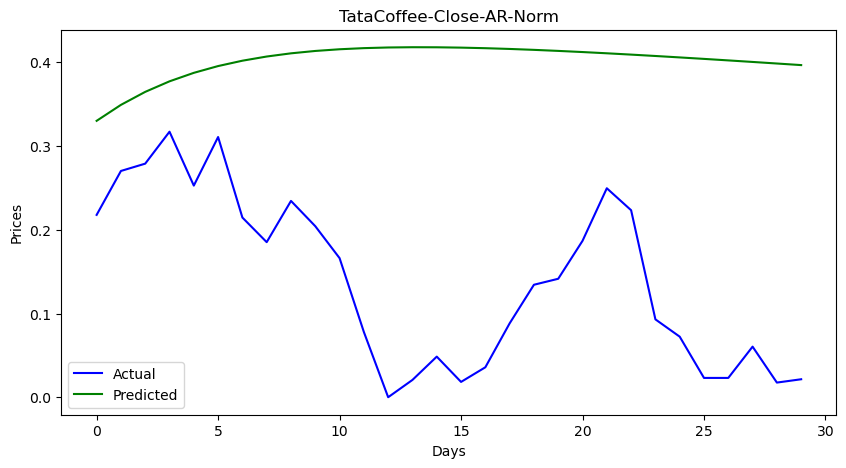

In [17]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-AR-Norm","Days","Prices")

In [18]:
len(data1)

151

In [19]:
y_test

array([[0.21780604],
       [0.27027027],
       [0.27901431],
       [0.31717011],
       [0.25278219],
       [0.31081081],
       [0.21462639],
       [0.18521463],
       [0.23449921],
       [0.20429253],
       [0.16613672],
       [0.07790143],
       [0.        ],
       [0.02066773],
       [0.04848967],
       [0.01828299],
       [0.03577107],
       [0.08823529],
       [0.13434022],
       [0.14149444],
       [0.18680445],
       [0.24960254],
       [0.22337043],
       [0.09300477],
       [0.07233704],
       [0.02305246],
       [0.02305246],
       [0.06041335],
       [0.01748808],
       [0.02146264]])

In [20]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [21]:
aTestNormTable

,ClosePrice
0,0.217806
1,0.27027
2,0.279014
3,0.31717
4,0.252782
5,0.310811
6,0.214626
7,0.185215
8,0.234499
9,0.204293


In [22]:
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)

In [23]:
actual_stock_price_test_ori

array([[186.6 ],
       [189.9 ],
       [190.45],
       [192.85],
       [188.8 ],
       [192.45],
       [186.4 ],
       [184.55],
       [187.65],
       [185.75],
       [183.35],
       [177.8 ],
       [172.9 ],
       [174.2 ],
       [175.95],
       [174.05],
       [175.15],
       [178.45],
       [181.35],
       [181.8 ],
       [184.65],
       [188.6 ],
       [186.95],
       [178.75],
       [177.45],
       [174.35],
       [174.35],
       [176.7 ],
       [174.  ],
       [174.25]])

In [24]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [25]:
actual_stock_price_test_oriA

,ClosePrice
0,186.6
1,189.9
2,190.45
3,192.85
4,188.8
5,192.45
6,186.4
7,184.55
8,187.65
9,185.75


In [26]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [27]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

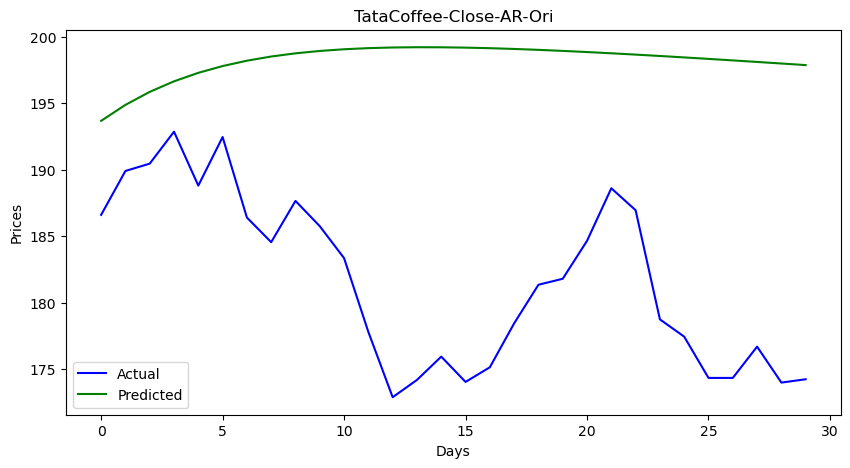

In [28]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-AR-Ori","Days","Prices")

In [29]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 17.93122936900753
maPe-Testset: 0.09217872921528035


C:\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [30]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [31]:
forecast

array([0.39481479, 0.39288156, 0.39093398, 0.38897445])

In [32]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [33]:
forecast_stock_price_test_oriF

,Closefore
0,197.73385
1,197.61225
2,197.489747
3,197.366493


In [34]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

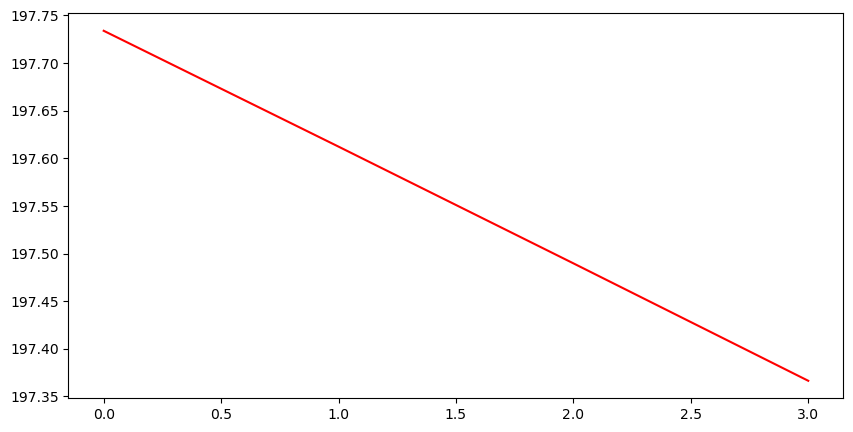

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")